In [112]:
from PyHessian.pyhessian.hessian import hessian
from PyHessian.density_plot import get_esd_plot
from hessian_utils import *
from PyHessian.pyhessian.utils import *
import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets, transforms
# from keras.datasets import mnist
import matplotlib.pyplot as plt 
import time
import copy


# PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
# How to do this?
import os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
%matplotlib inline

In [113]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)
cuda = torch.cuda.is_available()
torch.autograd.set_detect_anomaly(True)

cpu


In [114]:
mnist_trainset = datasets.MNIST(root='./data/mnist', train=True, download=True, transform=transforms.ToTensor())
mnist_fashion_trainset = datasets.FashionMNIST(root='./data/fashion_mnist', train=True, download=True, transform=transforms.ToTensor())
cifar_trainset = datasets.CIFAR10(root='./data/cifar10', train=True, download=True, transform=transforms.ToTensor())
# Getting mnist test data
mnist_testset = datasets.MNIST(root='./data/mnist', train=False, download=True, transform=transforms.ToTensor())
mnist_fashion_testset = datasets.FashionMNIST(root='./data/fashion_mnist', train=False, download=True, transform=transforms.ToTensor())
cifar_testset = datasets.CIFAR10(root='./data/cifar10', train=False, download=True, transform=transforms.ToTensor())

torch.manual_seed(42)

Files already downloaded and verified
Files already downloaded and verified


In [115]:
train_X = mnist_trainset.data
train_y = mnist_trainset.targets
test_X = mnist_testset.data
test_y = mnist_testset.targets

In [116]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 100)
        self.fc2 = nn.Linear(100, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(10, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.linear = nn.Sequential(
            nn.Linear(16*7*7, 16),
            nn.ReLU(),
            nn.Linear(16, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(-1, 16*7*7)
        x = self.linear(x)
        return x
    

# def nodewise_trace(model, hessian : hessian):
#     loader = hessian
    

In [117]:
train_X = (train_X / 255.0).to(device)
test_X = (test_X / 255.0).to(device)
train_y = torch.tensor(train_y, dtype=torch.int64).to(device)
test_y = torch.tensor(test_y, dtype=torch.int64).to(device)

C:\Users\Rajeev Wankar\AppData\Local\Temp\ipykernel_32200\3878040559.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_y = torch.tensor(train_y, dtype=torch.int64).to(device)
C:\Users\Rajeev Wankar\AppData\Local\Temp\ipykernel_32200\3878040559.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_y = torch.tensor(test_y, dtype=torch.int64).to(device)


In [118]:
# For convnet, change dimensions of input
train_X = train_X.unsqueeze(1)
test_X = test_X.unsqueeze(1)

In [119]:
dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_X[:1000], train_y[:1000]),
    batch_size=32, shuffle=True)
hessian_loader = []
# hessian_loader contains all 1000 images

for i in range(50):
    hessian_loader.append((train_X[i].unsqueeze(0), train_y[i].unsqueeze(0)))

In [120]:
model_SGD = ConvNet().to(device)
model_Adam = copy.deepcopy(model_SGD)
# model_randnewt = copy.deepcopy(model_SGD)
criterion = nn.CrossEntropyLoss()
optimizer_SGD = torch.optim.SGD(model_SGD.parameters(), lr=1e-2)
optimizer_Adam = torch.optim.Adam(model_Adam.parameters(), lr=1e-3)

In [121]:
train_losses_SGD = []
train_losses_Adam = []
traces_SGD = []
traces_Adam = []
epochs = 100
k = 100

# hessian_sgd = hessian(model_SGD, criterion, dataloader=hessian_loader, cuda=cuda)
# hessian_adam = hessian(model_Adam, criterion, dataloader=hessian_loader, cuda=cuda)
# traces_SGD.append(np.mean(hessian_sgd.trace()))
# traces_Adam.append(np.mean(hessian_adam.trace()))

In [122]:
# hessian_sgd = hessian(model_SGD, criterion, dataloader=hessian_loader, cuda=cuda)
# hessian_adam = hessian(model_Adam, criterion, dataloader=hessian_loader, cuda=cuda)
# get_esd_plot(*hessian_sgd.density(), title='SGD')
# get_esd_plot(*hessian_adam.density(), title='Adam')
# plt.show()

In [123]:
for epoch in range(epochs):
    model_SGD.train()
    model_Adam.train()
    # model_randnewt.train()

    for i, (x, y) in enumerate(dataloader):
        optimizer_SGD.zero_grad()
        # optimizer_Adam.zero_grad()
        #optimizer_randnewt.zero_grad()
        y_pred_SGD = model_SGD(x)
        # y_pred_Adam = model_Adam(x)
        loss_SGD = criterion(y_pred_SGD, y)
        # loss_Adam = criterion(y_pred_Adam, y)
        loss_SGD.backward()
        # loss_Adam.backward()
        optimizer_SGD.step()
        # optimizer_Adam.step()
        #optimizer_randnewt.step()
        # Randomized Newton Step
        train_losses_SGD.append(loss_SGD.item())
        # train_losses_Adam.append(loss_Adam.item())
        print(f"Epoch {epoch+1}/{epochs}, Batch {i+1}/{len(dataloader)}, Loss_SGD: {loss_SGD.item()}, Loss_Adam: {"loss_Adam.item()"}")
    # hessian_sgd = hessian(model_SGD, criterion, dataloader=hessian_loader, cuda=cuda)
    # hessian_adam = hessian(model_Adam, criterion, dataloader=hessian_loader, cuda=cuda)
    # hessian_randnewt = hessian(model_randnewt, criterion, dataloader=hessian_loader, cuda=cuda)
    # traces_SGD.append(np.mean(hessian_sgd.trace()))
    # traces_Adam.append(np.mean(hessian_adam.trace()))
    #print(f"Epoch {epoch+1}/{epochs}, Trace_SGD: {traces_SGD[-1]}, Trace_Adam: {traces_Adam[-1]}")

Epoch 1/100, Batch 1/32, Loss_SGD: 2.2983806133270264, Loss_Adam: loss_Adam.item()
Epoch 1/100, Batch 2/32, Loss_SGD: 2.3277862071990967, Loss_Adam: loss_Adam.item()
Epoch 1/100, Batch 3/32, Loss_SGD: 2.299635410308838, Loss_Adam: loss_Adam.item()
Epoch 1/100, Batch 4/32, Loss_SGD: 2.2792861461639404, Loss_Adam: loss_Adam.item()
Epoch 1/100, Batch 5/32, Loss_SGD: 2.3018062114715576, Loss_Adam: loss_Adam.item()
Epoch 1/100, Batch 6/32, Loss_SGD: 2.315497636795044, Loss_Adam: loss_Adam.item()
Epoch 1/100, Batch 7/32, Loss_SGD: 2.314105272293091, Loss_Adam: loss_Adam.item()
Epoch 1/100, Batch 8/32, Loss_SGD: 2.3205254077911377, Loss_Adam: loss_Adam.item()
Epoch 1/100, Batch 9/32, Loss_SGD: 2.304403066635132, Loss_Adam: loss_Adam.item()
Epoch 1/100, Batch 10/32, Loss_SGD: 2.327603340148926, Loss_Adam: loss_Adam.item()
Epoch 1/100, Batch 11/32, Loss_SGD: 2.320263385772705, Loss_Adam: loss_Adam.item()
Epoch 1/100, Batch 12/32, Loss_SGD: 2.354384660720825, Loss_Adam: loss_Adam.item()
Epoch 1/

c:\Users\Rajeev Wankar\Desktop\Aarsh IITGN\Project Course - Sem 4\DeepHessian\PyHessian\density_plot.py:72: ComplexWarning: Casting complex values to real discards the imaginary part
  density_output[i, j] = np.sum(tmp_result * weights[i, :])


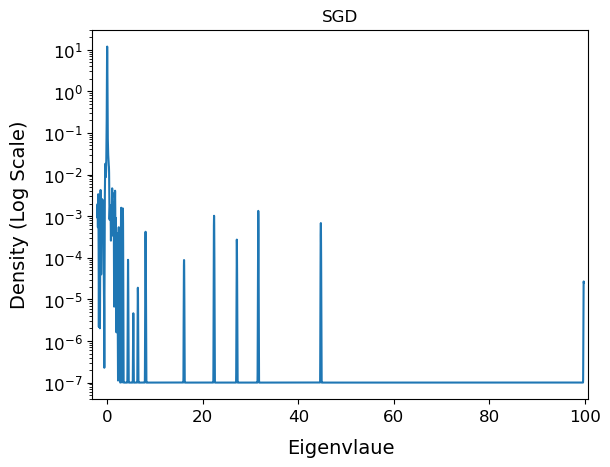

In [124]:
hess = hessian(model_SGD, criterion, dataloader=hessian_loader, cuda=cuda)
get_esd_plot(*hess.density(), title='SGD')

In [125]:
layer_trace = hess.layer_wise_trace(maxIter=100)
mean_layer_trace = [np.mean(layer_trace[i]) for i in range(len(layer_trace))]
lenarr = [params.numel() for params in model_SGD.parameters()]
per_parameter_trace = [mean_layer_trace[i]/lenarr[i] for i in range(len(mean_layer_trace))]
print(mean_layer_trace)
print(per_parameter_trace)
print(sum(mean_layer_trace))
print(np.mean(hess.trace(maxIter=100)))

[0.15517096115010126, 0.05368946585804224, 6.054249718075707, 0.06295951579374318, 231.54490968657703, 0.045479220938623735, 53.29524385012113, 0.07052804939448834]
[0.0017241217905566808, 0.005368946585804224, 0.0042043400819970185, 0.0039349697371089485, 0.018458618438024318, 0.0028424513086639834, 0.33309527406325706, 0.007052804939448834]
291.2822304679089
283.3067696149959


In [126]:

# (get_esd_plot(*hess.density(), title='SGD'))
# plt.show()

In [127]:
# (get_esd_plot(*hess.density(), title='SGD'))

In [128]:
# Finding number of parameters in model
total_params = 0
for param in model_SGD.parameters():
    total_params += param.numel()

print(f"Total number of parameters in model: {total_params}")

Total number of parameters in model: 14286


In [129]:
print(lenarr)

[90, 10, 1440, 16, 12544, 16, 160, 10]


In [134]:
print(model_SGD.state_dict().keys())

odict_keys(['conv.0.weight', 'conv.0.bias', 'conv.3.weight', 'conv.3.bias', 'linear.0.weight', 'linear.0.bias', 'linear.2.weight', 'linear.2.bias'])


In [130]:
# nodewise_traces = []

# # Loop through the parameters and compute the second-order derivatives
# for param in model_SGD.parameters():
#     if param.grad is not None:
#         # Initialize a list for the diagonal of the Hessian for each parameter
#         param_trace = 0
#         # Compute the second derivative (Hessian) for each element of the parameter
#         for grad in param.grad.view(-1):
#             # Compute the second derivative with respect to each element in the gradient
#             second_order_derivative = torch.autograd.grad(grad, param, retain_graph=True, create_graph = True)
#             param_trace += second_order_derivative[0].sum()  # Sum of second-order derivatives (trace)
#         nodewise_traces.append(param_trace)
#     else:
#         print("parameter is None")
# # The nodewise traces now contain the trace of the Hessian for each parameter
# print(nodewise_traces)

In [131]:
# import torch
# import torch.nn as nn
# import numpy as np
# from torchvision import datasets, transforms
# import matplotlib.pyplot as plt
# import copy
# import time

# # Define the model
# class Net(nn.Module):
#     def __init__(self):
#         super(Net, self).__init__()
#         self.fc1 = nn.Linear(28*28, 100)
#         self.fc2 = nn.Linear(100, 10)

#     def forward(self, x):
#         x = x.view(-1, 28*28)
#         x = torch.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x

# # Load data
# train_X = mnist_trainset.data
# train_y = mnist_trainset.targets
# train_X = train_X / 255.0  # Normalize the data
# train_X = train_X.to(device).float()
# train_y = torch.tensor(train_y, dtype=torch.int64).to(device)

# # Model, optimizer, loss function
# model_SGD = Net().to(device)
# optimizer_SGD = torch.optim.SGD(model_SGD.parameters(), lr=1e-3)
# criterion = nn.CrossEntropyLoss()

# # Training loop
# for epoch in range(epochs):
#     model_SGD.train()
#     for i, (x, y) in enumerate(dataloader):
#         optimizer_SGD.zero_grad()
#         y_pred_SGD = model_SGD(x)
#         loss_SGD = criterion(y_pred_SGD, y)
#         loss_SGD.backward(create_graph=True)
#         optimizer_SGD.step()

# # Calculate second-order derivatives (Hessian)
# nodewise_traces = []

# for param in model_SGD.parameters():
#     if param.grad is not None:
#         param_trace = 0
#         for grad_element in param.grad.view(-1):
#             second_order_derivative = torch.autograd.grad(grad_element, param, retain_graph=True, create_graph=True)[0]
#             param_trace += second_order_derivative.sum()
#         nodewise_traces.append(param_trace)

# print("Nodewise Traces of the Hessian:")
# print(nodewise_traces)
